In [1]:
import yfinance as yf
import pandas as pd
import numpy as np

In [2]:
ticker = "EQNR.OL"
start = "2000-01-01"
end = None

In [3]:
df = yf.download(ticker, start=start, end=end, auto_adjust=False, progress=False)

if df.empty:
    raise ValueError(f"Ingen data for {ticker} i perioden.")
    
px = df["Adj Close"].dropna() #.rename(columns={"Adj Close":"price"})
px.columns = ["price"]
px = px.reset_index()
px

,Date,price
0,2000-01-03,22.131046
1,2000-01-04,21.777729
2,2000-01-05,21.328041
3,2000-01-06,22.098932
4,2000-01-07,22.452255
...,...,...
6629,2026-02-23,277.500000
6630,2026-02-24,280.200012
6631,2026-02-25,279.299988
6632,2026-02-26,279.000000


In [4]:
import matplotlib.pyplot as plt
from statsmodels.graphics.tsaplots import plot_acf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import durbin_watson

In [5]:
# Prepare price series and compute returns
if 'Date' in px.columns:
    px = px.set_index('Date')
returns = px['price'].pct_change().dropna()
returns.name = 'returns'
returns.head()

Date
2000-01-04   -0.015965
2000-01-05   -0.020649
2000-01-06    0.036144
2000-01-07    0.015988
2000-01-10    0.015737
Name: returns, dtype: float64

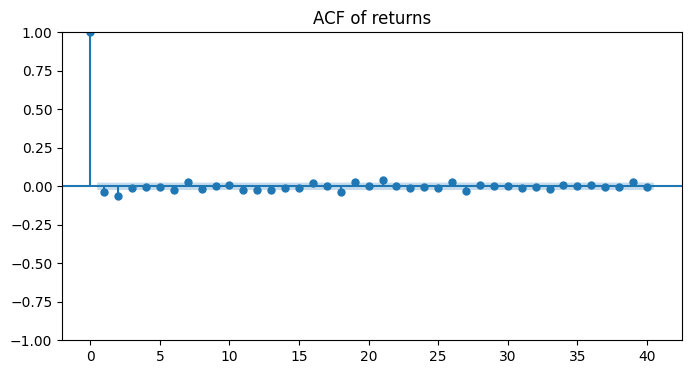

In [6]:
# ACF plot
fig, ax = plt.subplots(figsize=(8,4))
plot_acf(returns, lags=40, ax=ax, alpha=0.05)
ax.set_title('ACF of returns')
plt.show()

In [8]:
# Ljung-Box and Durbin-Watson tests
lb = acorr_ljungbox(returns, lags=[10,20], return_df=True)
lb_sq = acorr_ljungbox(returns**2, lags=[10,20], return_df=True)
dw = durbin_watson(returns)
print('Ljung-Box test for returns (lags 10 & 20):')
print(lb)
print('Ljung-Box test for squared returns (lags 10 & 20):')
print(lb_sq)
print(f'\nDurbin-Watson: {dw:.4f}')

Ljung-Box test for returns (lags 10 & 20):
      lb_stat     lb_pvalue
10  47.230404  8.573755e-07
20  77.932060  8.784839e-09
Ljung-Box test for squared returns (lags 10 & 20):
        lb_stat      lb_pvalue
10  1062.607305  6.056074e-222
20  1728.620830   0.000000e+00

Durbin-Watson: 2.0773
